In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")


def adf_test(x):
    indices = ['ADF: Test statistic', 'p value', '# of Lags', '# of Observations']

    test = adfuller(x, autolag='AIC') # Perform

    #Dickey-Fuller test

    results = pd.Series(test[:4], index=indices)
    
    for key, value in test[4].items():

        results[f'Critical Value ({key})'] = value
        
    if results['p value'] <= 0.05: # (p-value < 0.05 (alpha=5%))

        print("Reject the null hypothesis (H0), \nthe data is stationary.")

    else:

        print("Fail to reject the null hypothesis (HO), \nthe data is not stationary.")
    
    return results

def kpss_test(x):
    indices = ['KPSS: Test statistic', 'p value', '# of Lags']

    test = kpss(x)

    results = pd.Series(test[:3], index=indices)

    for key, value in test[3].items():

        results[f'Critical Value ({key})'] = value

    if results['p value'] <= 0.05: # (p-value < 0.05 (alpha=5%))

        print("Reject the null hypothesis (H0), \nthe data is not stationary.")

    else:

        print("Fail to reject the null hypothesis (HO), \nthe data is stationary.")
    return results

## 1. Load và Khám phá Dữ liệu

<Axes: title={'center': 'Log Price Gold SJC (Sell)'}, xlabel='Date'>

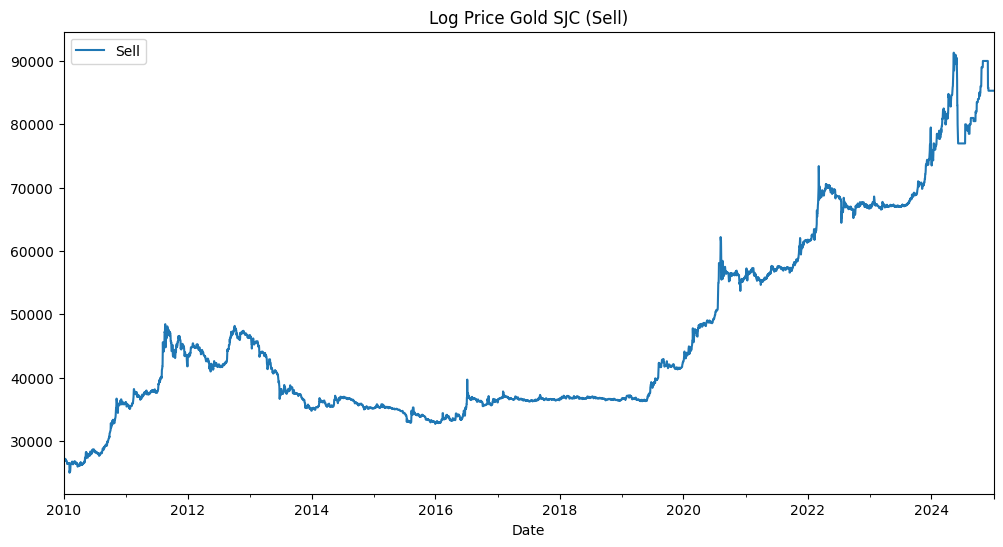

In [23]:
df = pd.read_excel('data/GoldSJC_2010_2025.xlsx', index_col='Date', parse_dates=True)
df = df[['Sell']].resample('D').ffill()
df_log = df.copy()
df_log.plot(figsize=(12,6), title='Log Price Gold SJC (Sell)')

In [24]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5480 entries, 2010-01-01 to 2025-01-01
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sell    5480 non-null   int64
dtypes: int64(1)
memory usage: 85.6 KB


## a) Phân rã dữ liệu (Decomposition) và Nhận xét

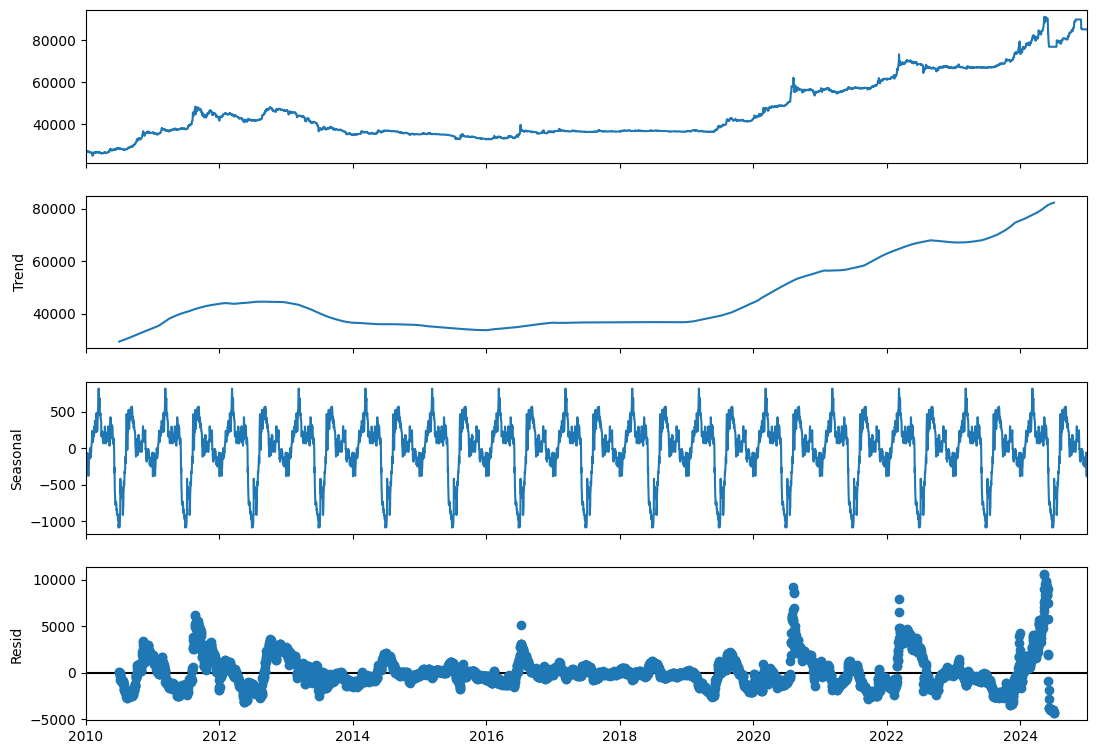

In [25]:
decomposition = seasonal_decompose(df_log, model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

## b) Kiểm định tính dừng và Tương quan

Fail to reject the null hypothesis (HO), 
the data is not stationary.
ADF Test: ADF: Test statistic        0.525137
p value                    0.985617
# of Lags                 13.000000
# of Observations       5466.000000
Critical Value (1%)       -3.431547
Critical Value (5%)       -2.862069
Critical Value (10%)      -2.567052
dtype: float64
Reject the null hypothesis (H0), 
the data is not stationary.

KPSS Test: KPSS: Test statistic      8.334809
p value                   0.010000
# of Lags                44.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


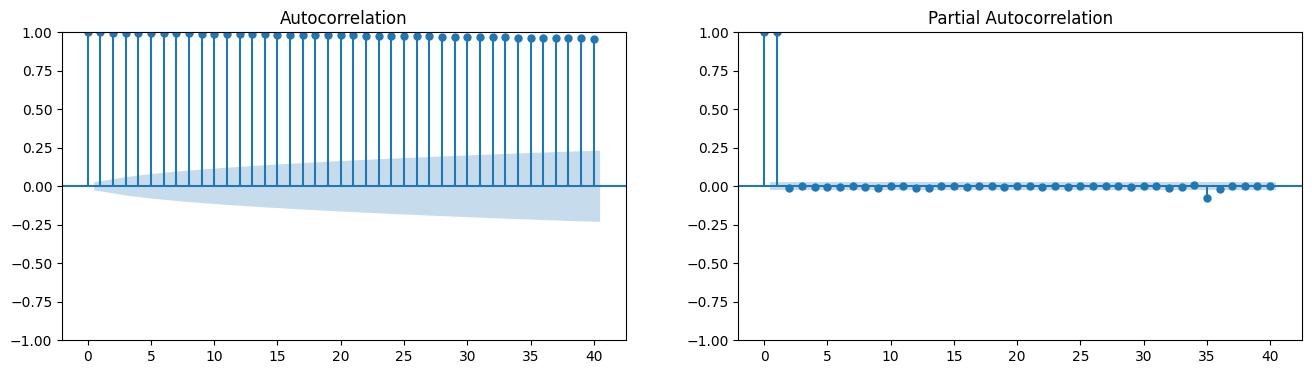

In [26]:
print("ADF Test:", adf_test(df_log))
print("\nKPSS Test:", kpss_test(df_log))

# ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log, ax=ax1, lags=40)
plot_pacf(df_log, ax=ax2, lags=40)
plt.show()

Reject the null hypothesis (H0), 
the data is stationary.
ADF Test: ADF: Test statistic    -1.865243e+01
p value                 2.050308e-30
# of Lags               1.200000e+01
# of Observations       5.466000e+03
Critical Value (1%)    -3.431547e+00
Critical Value (5%)    -2.862069e+00
Critical Value (10%)   -2.567052e+00
dtype: float64
Fail to reject the null hypothesis (HO), 
the data is stationary.

KPSS Test: KPSS: Test statistic     0.360912
p value                  0.094004
# of Lags                9.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


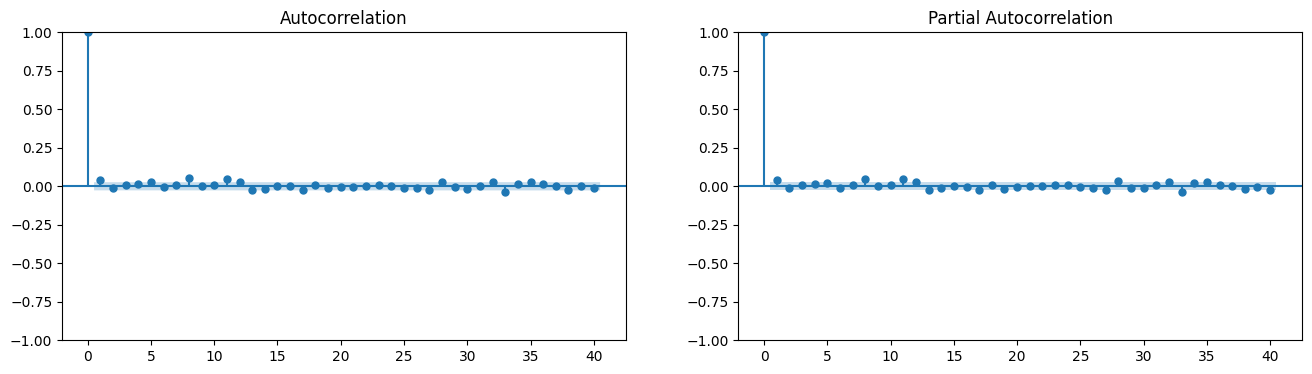

In [27]:
# Lấy sai phân bậc 1
df_log_diff = df_log.diff().dropna()
print("ADF Test:", adf_test(df_log_diff))
print("\nKPSS Test:", kpss_test(df_log_diff))

# ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_log_diff, ax=ax1, lags=40)
plot_pacf(df_log_diff, ax=ax2, lags=40)
plt.show()

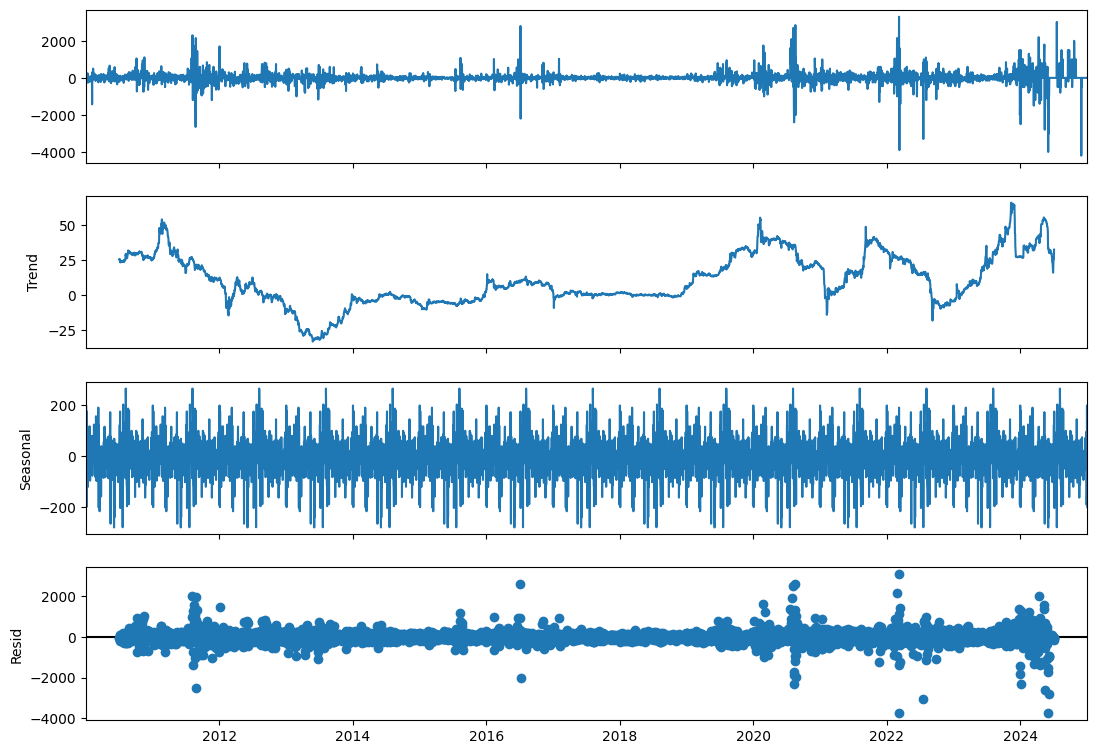

In [28]:
decomposition = seasonal_decompose(df_log_diff, model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

## c) Fit mô hình ARIMA (80% Train), Đánh giá và Dự báo tương lai

Train: 4384 dòng (2010-01-01 → 2022-01-01)
Test : 1096  dòng (2022-01-02 → 2025-01-01)
                               SARIMAX Results                                
Dep. Variable:                   Sell   No. Observations:                 4384
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -30155.703
Date:                Thu, 04 Jun 2026   AIC                          60319.406
Time:                        18:55:52   BIC                          60344.948
Sample:                    01-01-2010   HQIC                         60328.418
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             7.9170      3.684      2.149      0.032       0.696      15.138
ar.L1         -0.8407      0.035    -23.791 

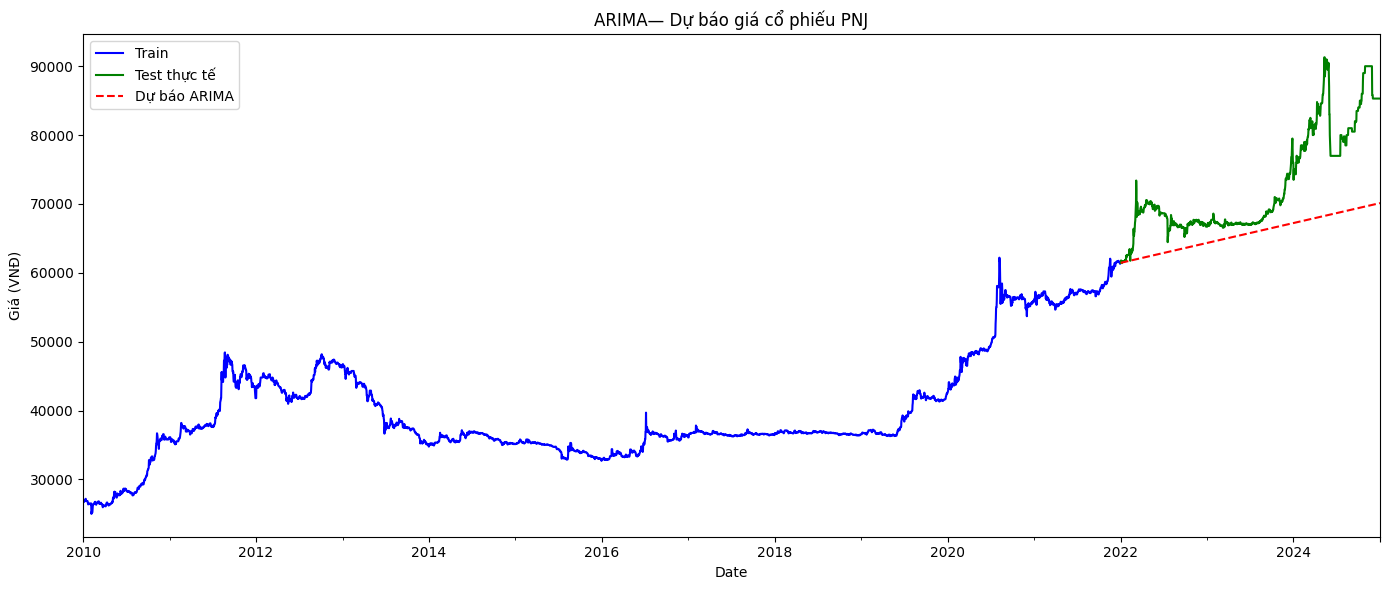

In [ ]:
train_size = int(len(df_log) * 0.8)
train = df_log['Sell'][:train_size]
test  = df_log['Sell'][train_size:]
print(f"Train: {len(train)} dòng ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test : {len(test)}  dòng ({test.index[0].date()} → {test.index[-1].date()})")


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=60307.599, Time=2.51 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=60323.579, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=60322.929, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=60322.806, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=60326.528, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=60321.280, Time=0.98 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=60320.940, Time=1.01 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=60325.047, Time=1.03 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=60322.058, Time=1.79 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=60319.401, Time=0.96 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=60323.126, Time=1.08 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=60322.993, Time=0.60 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=60306.180, Time=3.31 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=60317.766, Time=2.75 sec
 ARIMA(3,1,4)(0,0,0

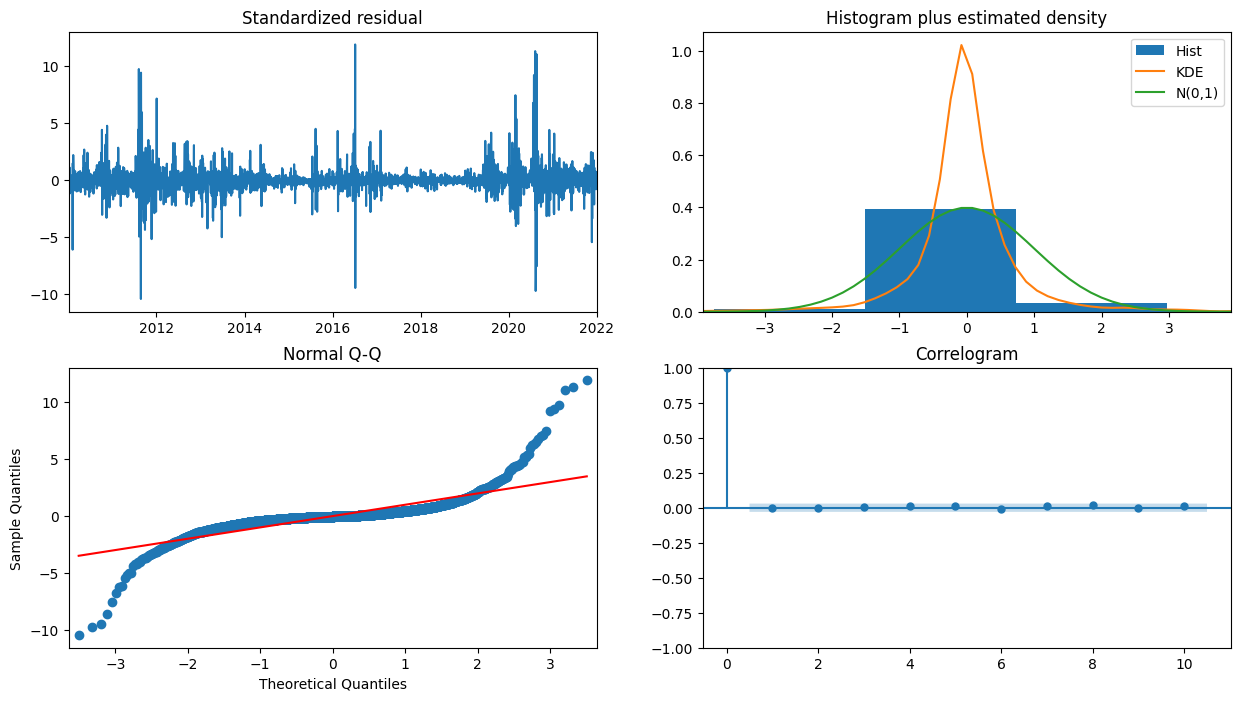

In [36]:
stepwise_model = auto_arima(train, trace=True, suppress_warnings=True)
print(stepwise_model.summary())
stepwise_model.plot_diagnostics(figsize=(15, 8))
plt.show()

                               SARIMAX Results                                
Dep. Variable:                   Sell   No. Observations:                 4384
Model:                 ARIMA(5, 1, 5)   Log Likelihood              -30132.505
Date:                Thu, 04 Jun 2026   AIC                          60289.011
Time:                        19:37:21   BIC                          60365.637
Sample:                    01-01-2010   HQIC                         60316.047
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             7.9191      3.851      2.056      0.040       0.371      15.467
ar.L1          0.4063      0.050      8.186      0.000       0.309       0.504
ar.L2          0.2303      0.072      3.207      0.0

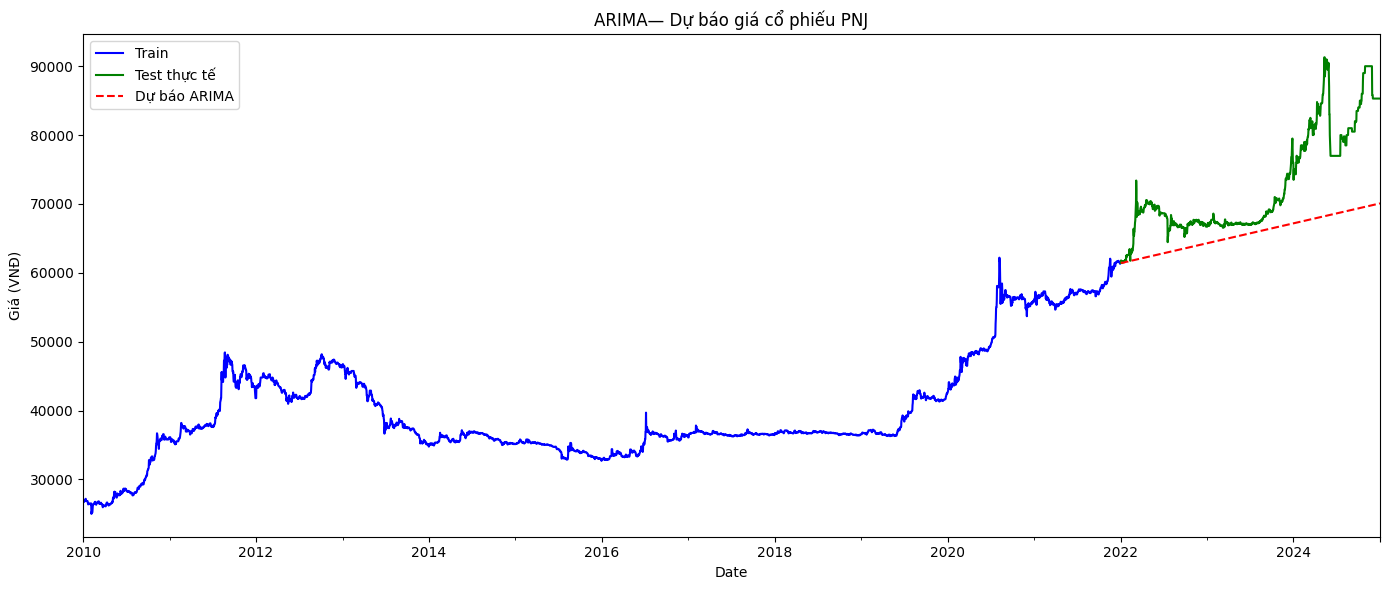

In [ ]:

# ── Fit ARIMA(1,1,0) ─────────────────────────────────────────
model = ARIMA(train, order=(1, 1, 0), trend='t') 
fitted = model.fit()
print(fitted.summary())
'''
   MAE  : 6,868.96
   RMSE : 8,862.83
   MAPE : 8.83%
210
    MAE  : 6,872.15
   RMSE : 8,865.32
   MAPE : 8.83%
   5,1,5
   MAE  : 6,917.99
   RMSE : 8,901.08
   MAPE : 8.90%
'''
# ── Dự báo trên tập test ─────────────────────────────────────
forecast = fitted.forecast(steps=len(test))
forecast.index = test.index

# ── Đánh giá mô hình ─────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"\n📊 Đánh giá mô hình ARIMA(1,1,0):")
print(f"   MAE  : {mae:,.2f}")
print(f"   RMSE : {rmse:,.2f}")
print(f"   MAPE : {mape:.2f}%")

# ── Vẽ biểu đồ ───────────────────────────────────────────────
plt.figure(figsize=(14, 6))
train.plot(label='Train', color='blue')
test.plot(label='Test thực tế', color='green')
forecast.plot(label='Dự báo ARIMA', color='red', linestyle='--')
plt.title('ARIMA— Dự báo giá cổ phiếu PNJ')
plt.xlabel('Date')
plt.ylabel('Giá (VNĐ)')
plt.legend()
plt.tight_layout()
plt.show()

## d) Expanding Window và Sliding Window

🔄 Expanding Window đang chạy...
   Bước 0/1096
   Bước 100/1096
   Bước 200/1096
   Bước 300/1096
   Bước 400/1096
   Bước 500/1096
   Bước 600/1096
   Bước 700/1096
   Bước 800/1096
   Bước 900/1096
   Bước 1000/1096

🔄 Sliding Window đang chạy...
   Bước 0/1096
   Bước 100/1096
   Bước 200/1096
   Bước 300/1096
   Bước 400/1096
   Bước 500/1096
   Bước 600/1096
   Bước 700/1096
   Bước 800/1096
   Bước 900/1096
   Bước 1000/1096

📊 Expanding Window:
   MAE  : 206.97
   RMSE : 466.71
   MAPE : 0.28%

📊 Sliding Window:
   MAE  : 207.65
   RMSE : 468.56
   MAPE : 0.28%


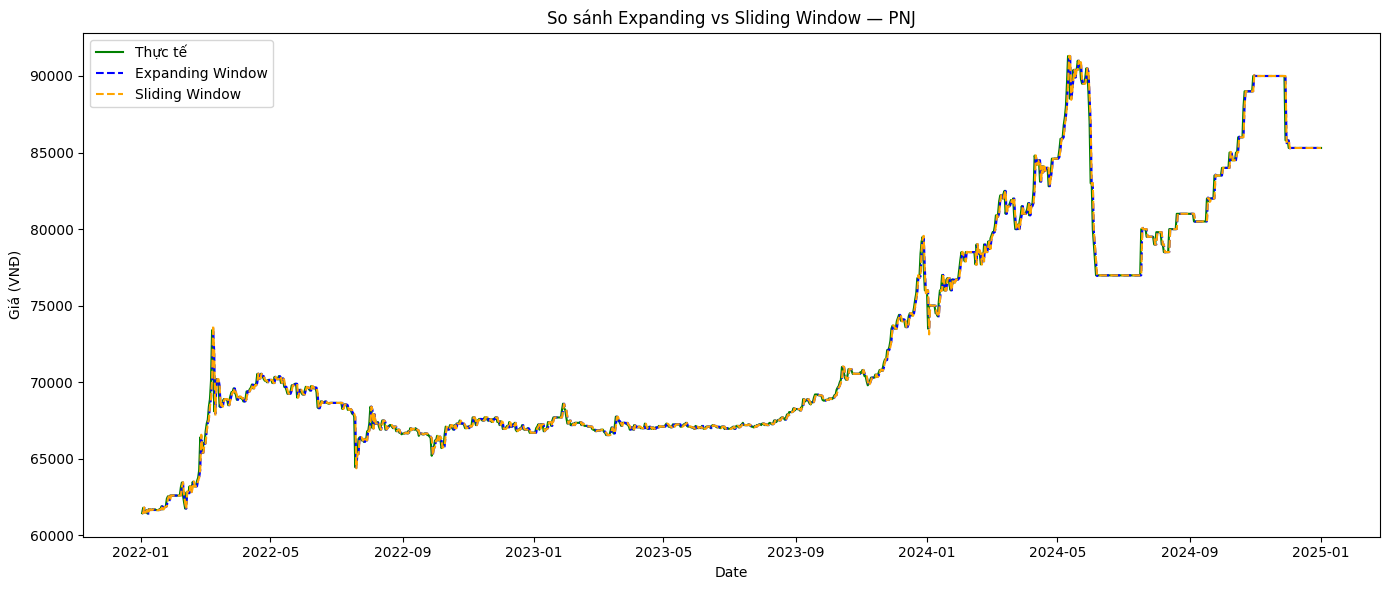


Phương pháp                 MAE       RMSE     MAPE
ARIMA(1,1,0)             11,522     13,042   20.54%
Expanding                   207        467    0.28%
Sliding(252)                208        469    0.28%


In [35]:

from sklearn.metrics import mean_squared_error, mean_absolute_error

close = df_log['Sell'].values

train_size = int(len(close) * 0.8)

# ══════════════════════════════════════════════════════════════
# KỸ THUẬT 1: EXPANDING WINDOW
# Mỗi bước: dùng toàn bộ dữ liệu từ đầu đến hiện tại để dự báo
# ══════════════════════════════════════════════════════════════
print("🔄 Expanding Window đang chạy...")
expanding_preds = []

for i in range(train_size, len(close)):
    train_exp = close[:i]
    model = ARIMA(train_exp, order=(1, 1, 0))
    fitted = model.fit()
    pred = fitted.forecast(steps=1)[0]
    expanding_preds.append(pred)
    if (i - train_size) % 100 == 0:
        print(f"   Bước {i - train_size}/{len(close) - train_size}")

# ══════════════════════════════════════════════════════════════
# KỸ THUẬT 2: SLIDING WINDOW
# Mỗi bước: chỉ dùng 252 ngày gần nhất (1 năm) để dự báo
# ══════════════════════════════════════════════════════════════
print("\n🔄 Sliding Window đang chạy...")
sliding_preds = []
window_size = 252  # 1 năm giao dịch

for i in range(train_size, len(close)):
    train_sld = close[max(0, i - window_size):i]
    model = ARIMA(train_sld, order=(1, 1, 0))
    fitted = model.fit()
    pred = fitted.forecast(steps=1)[0]
    sliding_preds.append(pred)
    if (i - train_size) % 100 == 0:
        print(f"   Bước {i - train_size}/{len(close) - train_size}")

# ── Tính metrics ─────────────────────────────────────────────
actual = close[train_size:]
dates  = df_log.index[train_size:]

def metrics(actual, pred, name):
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"\n📊 {name}:")
    print(f"   MAE  : {mae:,.2f}")
    print(f"   RMSE : {rmse:,.2f}")
    print(f"   MAPE : {mape:.2f}%")
    return mae, rmse, mape

mae_exp, rmse_exp, mape_exp = metrics(actual, expanding_preds, "Expanding Window")
mae_sld, rmse_sld, mape_sld = metrics(actual, sliding_preds,   "Sliding Window")

# ── Vẽ biểu đồ so sánh ───────────────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(dates, actual,           label='Thực tế',           color='green')
plt.plot(dates, expanding_preds,  label='Expanding Window',  color='blue',   linestyle='--')
plt.plot(dates, sliding_preds,    label='Sliding Window',    color='orange', linestyle='--')
plt.title('So sánh Expanding vs Sliding Window — PNJ')
plt.xlabel('Date')
plt.ylabel('Giá (VNĐ)')
plt.legend()
plt.tight_layout()
plt.savefig('expanding_sliding.png', dpi=150)
plt.show()

# ── Bảng so sánh ─────────────────────────────────────────────
print("\n" + "="*50)
print(f"{'Phương pháp':<20} {'MAE':>10} {'RMSE':>10} {'MAPE':>8}")
print("="*50)
print(f"{'ARIMA(1,1,0)':<20} {'11,522':>10} {'13,042':>10} {'20.54%':>8}")
print(f"{'Expanding':<20} {mae_exp:>10,.0f} {rmse_exp:>10,.0f} {mape_exp:>7.2f}%")
print(f"{'Sliding(252)':<20} {mae_sld:>10,.0f} {rmse_sld:>10,.0f} {mape_sld:>7.2f}%")
print("="*50)

### So sánh và Đánh giá
- Cả hai kỹ thuật Expanding và Sliding Window đều cho thấy mô hình ARIMA có khả năng dự báo giá vàng khá ổn định.
- Sliding Window thường được ưu tiên khi thị trường có những thay đổi cấu trúc nhanh chóng trong thời gian ngắn.